# 구글 드라이브 마운트

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 데이터 경로 생성

In [ ]:
import os

# Create the directories if they don't exist
os.makedirs('/content/llm_dataset/test', exist_ok=True)
os.makedirs('/content/llm_dataset/train', exist_ok=True)

print("Directories '/content/llm_dataset/test' and '/content/llm_dataset/train' created.")

Directories '/content/llm_dataset/test' and '/content/llm_dataset/train' created.


# 데이터 압축 해제

In [ ]:
!unzip -q /content/drive/MyDrive/test_조립모듈/VL_중간조립모듈_zipped.zip -d /content/llm_dataset/test
!unzip -q /content/drive/MyDrive/test_조립모듈/VS_중간조립모듈_zipped.zip -d /content/llm_dataset/test
!unzip -q /content/drive/MyDrive/train_조립모듈/TL_중간조립모듈_zipped.zip -d /content/llm_dataset/train
!unzip -q /content/drive/MyDrive/train_조립모듈/TS_중간조립모듈_zipped.zip -d /content/llm_dataset/train

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.


In [ ]:
import glob

# JSON 파일 개수 카운트
train_files = glob.glob('/content/llm_dataset/train/**/*.json', recursive=True)
test_files = glob.glob('/content/llm_dataset/test/**/*.json', recursive=True)

train_count = len(train_files)
test_count = len(test_files)
total_count = train_count + test_count

print("=== 데이터셋 분할 및 개수 확인 ===")
print(f"학습(Train) 데이터: {train_count:,}개")
print(f"검증/평가(Test) 데이터: {test_count:,}개")
print(f"전체 데이터: {total_count:,}개")

if total_count > 0:
    train_ratio = (train_count / total_count) * 100
    test_ratio = (test_count / total_count) * 100
    print(f"\n분할 비율: 학습 {train_ratio:.1f}% : 검증 {test_ratio:.1f}%")

=== 데이터셋 분할 및 개수 확인 ===
학습(Train) 데이터: 174,267개
검증/평가(Test) 데이터: 21,799개
전체 데이터: 196,066개

분할 비율: 학습 88.9% : 검증 11.1%


# 필요 라이브러리 설치

In [ ]:
!pip install ultralytics
!pip install grad-cam
!pip install chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 448.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 4.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.7-py3-none-any.whl size=53345 sha256=3b000488ff395c4b774c7ce4ff73964bf198863abd978320982fd63993b2fb01
  Stored in directory: /root/.cache/pip/wheels/91/36/f0/c2367865493d51b13369769181beca14603d17d6539a5922e3
Successfully built grad-cam
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 584.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━

# YOLO-ResNet 통합 파이프라인


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet18
import torchvision.transforms as transforms
from ultralytics import YOLO

# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ResNet 모델 정의
class AssemblyResNet(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        # 사전 학습된 ResNet18 로드
        self.model = resnet18(weights=None)

        # 미세 단차(1~2mm 나사선 등) 학습을 위해 모든 파라미터 동결 해제 (Fine-tuning)
        for param in self.model.parameters():
            param.requires_grad = True

        # 4-Class(완전체결, 부분체결, 미체결, 오류체결) 분류를 위해 마지막 FC 레이어 수정
        in_features = self.model.fc.in_features
        self.model.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.model(x)

# 1. ResNet 모델 로드
RESNET_WEIGHTS_PATH = '/content/drive/MyDrive/YOLO_ResNet/best_classification_resnet_finetuned.pth'
classification_model = AssemblyResNet(num_classes=4).to(device)
classification_model.load_state_dict(torch.load(RESNET_WEIGHTS_PATH, map_location=device))
classification_model.eval()

# 2. YOLO 모델 로드
YOLO_WEIGHTS_PATH = '/content/drive/MyDrive/YOLO_ResNet/yolo_train_results_v12/part_type_detection_v12/weights/best.pt'
eval_model = YOLO(YOLO_WEIGHTS_PATH)

# 3. Transform 및 클래스 정의
transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

resnet_classes = ['정상', '부분체결', '미체결', '오류체결']
print("모델 로드 완료! 이제 아래의 평가 셀을 실행하실 수 있습니다.")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
모델 로드 완료! 이제 아래의 평가 셀을 실행하실 수 있습니다.


# YOLO-ResNet 통합 성능 테스트

In [ ]:
import os
import glob
import json
import numpy as np
import cv2
import torch
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import classification_report

# ==========================================
# 1. 평가용 데이터 준비
# ==========================================
# 전체 테스트 데이터 탐색
test_jsons = sorted(glob.glob('/content/llm_dataset/test/**/*.json', recursive=True))
print(f"평가용 JSON 파일 수: {len(test_jsons)}")

# 체크포인트 파일명도 분리하여 꼬이지 않게 방지
CHECKPOINT_FILE = '/content/evaluation_checkpoint_test.json'

if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, 'r', encoding='utf-8') as f:
        checkpoint = json.load(f)
    processed_files = set(checkpoint.get('processed_files', []))
    yolo_gt = checkpoint.get('yolo_gt', [])
    yolo_pred = checkpoint.get('yolo_pred', [])
    resnet_gt = checkpoint.get('resnet_gt', [])
    resnet_pred = checkpoint.get('resnet_pred', [])

    # 기존 체크포인트에 잘못 저장된 정답 라벨들 일괄 수정 (재평가 방지)
    fix_map = {'완전체결 상태': '정상', '부분체결 상태': '부분체결', '미체결 상태': '미체결', '오류체결 상태': '오류체결'}
    resnet_gt = [fix_map.get(x, x) for x in resnet_gt]

    print(f"🔄 체크포인트 로드 완료: 이미 처리된 {len(processed_files)}개를 제외하고 이어서 진행합니다.")
else:
    processed_files = set()
    yolo_gt, yolo_pred = [], []
    resnet_gt, resnet_pred = [], []

# 아직 처리되지 않은 파일만 필터링
sample_jsons = [f for f in test_jsons if f not in processed_files]
print(f"▶ 남은 평가 대상: {len(sample_jsons)}개")

# 데이터셋에 실제로 들어있는 한글 상태값들까지 모두 매핑되도록 추가
status_mapping = {
    '0_Normal': '정상',
    '1_Partial': '부분체결',
    '2_Missing': '미체결',
    '3_Error': '오류체결',
    '완전체결 상태': '정상',
    '부분체결 상태': '부분체결',
    '미체결 상태': '미체결',
    '오류체결 상태': '오류체결'
}

# ==========================================
# 2. 모델 추론 진행
# ==========================================
for i, json_path in enumerate(tqdm(sample_jsons)):
    img_path = json_path.rsplit('.', 1)[0] + '.jpg'
    if not os.path.exists(img_path):
        processed_files.add(json_path)
        continue

    # JSON 기반 Ground Truth 로드
    with open(json_path, 'r', encoding='utf-8-sig') as f:
        data = json.load(f)

    gt_parts = []
    gt_statuses = []
    for ann in data.get('Annotation', []):
        part = ann.get('Annotation_part_type')
        status = ann.get('Subclass_status')
        if part and status:
            gt_parts.append(part)
            gt_statuses.append(status_mapping.get(status, status))

    if not gt_parts:
        processed_files.add(json_path)
        continue

    orig_img_bgr = cv2.imread(img_path)
    if orig_img_bgr is None:
        processed_files.add(json_path)
        continue

    orig_img_rgb = cv2.cvtColor(orig_img_bgr, cv2.COLOR_BGR2RGB)

    # YOLO 추론 최적화 (해상도 640 고정, 최대 탐지 개수 제한)
    results = eval_model.predict(img_path, conf=0.5, imgsz=640, max_det=10, agnostic_nms=False, verbose=False)[0]
    boxes_data = results.boxes.data.cpu().numpy()

    pred_parts = []
    pred_statuses = []

    for row in boxes_data:
        x1, y1, x2, y2, conf, cls = row
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        pred_parts.append(results.names[int(cls)])

        # ResNet 추론을 위한 Crop 및 Transform
        bw, bh = x2 - x1, y2 - y1
        mx, my = int(bw * 0.2), int(bh * 0.2)
        cx1, cy1 = max(0, x1 - mx), max(0, y1 - my)
        cx2, cy2 = min(orig_img_rgb.shape[1], x2 + mx), min(orig_img_rgb.shape[0], y2 + my)

        crop_pil = Image.fromarray(orig_img_rgb[cy1:cy2, cx1:cx2])
        w, h = crop_pil.size
        max_wh = max(w, h)
        padded = Image.new('RGB', (max_wh, max_wh), (0, 0, 0))
        padded.paste(crop_pil, ((max_wh - w) // 2, (max_wh - h) // 2))
        input_tensor = transform_val(padded.resize((224, 224))).unsqueeze(0).to(device)

        with torch.no_grad():
            outputs = classification_model(input_tensor)
            pred_idx = outputs.argmax(dim=1).item()
            pred_statuses.append(resnet_classes[pred_idx])

    # 매칭 및 지표 누적
    gt_parts.sort()
    pred_parts.sort()

    min_len_yolo = min(len(gt_parts), len(pred_parts))
    yolo_gt.extend(gt_parts[:min_len_yolo])
    yolo_pred.extend(pred_parts[:min_len_yolo])

    for gt in gt_parts[min_len_yolo:]:
        yolo_gt.append(gt)
        yolo_pred.append('None(Missed)')
    for p in pred_parts[min_len_yolo:]:
        yolo_gt.append('None(False_Alarm)')
        yolo_pred.append(p)

    gt_statuses.sort()
    pred_statuses.sort()

    min_len_resnet = min(len(gt_statuses), len(pred_statuses))
    resnet_gt.extend(gt_statuses[:min_len_resnet])
    resnet_pred.extend(pred_statuses[:min_len_resnet])

    for gt in gt_statuses[min_len_resnet:]:
        resnet_gt.append(gt)
        resnet_pred.append('None(Missed)')
    for p in pred_statuses[min_len_resnet:]:
        resnet_gt.append('None(False_Alarm)')
        resnet_pred.append(p)

    # 처리 완료 파일 기록
    processed_files.add(json_path)

    # 500개 처리할 때마다 진행상황 저장 (체크포인트)
    if (i + 1) % 500 == 0 or (i + 1) == len(sample_jsons):
        with open(CHECKPOINT_FILE, 'w', encoding='utf-8') as f:
            json.dump({
                'processed_files': list(processed_files),
                'yolo_gt': yolo_gt,
                'yolo_pred': yolo_pred,
                'resnet_gt': resnet_gt,
                'resnet_pred': resnet_pred
            }, f)

# ==========================================
# 3. 성능 결과 출력
# ==========================================
if len(yolo_gt) > 0:
    print("\n==========================================")
    print(f" 📊 Clean Test YOLO 부품 검출(Part Type) 성능 (총 {len(processed_files)}개 기준)")
    print("==========================================")
    print(classification_report(yolo_gt, yolo_pred, zero_division=0))

    print("\n==========================================")
    print(f" 📊 Clean Test ResNet 체결 상태(Status) 성능 (총 {len(processed_files)}개 기준)")
    print("==========================================")
    print(classification_report(resnet_gt, resnet_pred, zero_division=0))
else:
    print("평가 결과가 없습니다.")

평가용 JSON 파일 수: 21799
▶ 남은 평가 대상: 21799개


  0%|          | 0/21799 [00:00<?, ?it/s]


 📊 Clean Test YOLO 부품 검출(Part Type) 성능 (총 21799개 기준)
                   precision    recall  f1-score   support

             GPC형       0.97      0.90      0.94      4871
           GPL45형       0.91      0.80      0.85      2136
             GPL형       0.88      0.80      0.84      2903
            KCPC형       0.98      0.96      0.97     22653
           KCPLV형       1.00      0.98      0.99        88
           KRPPL형       0.95      0.94      0.95     13286
            KRPT형       0.90      0.93      0.92       142
           KRPUC형       0.94      0.93      0.93     14063
           KRPUL형       0.95      0.95      0.95        96
            KRPY형       0.94      0.94      0.94      4601
           KRPZA형       0.86      0.81      0.84        79
           KSPHL형       0.95      0.96      0.96        83
          KSPL45형       0.94      0.94      0.94      3113
           KSPPL형       0.84      0.87      0.85        30
None(False_Alarm)       0.00      0.00      0.00      1368
 

### 🧪 [Ablation Study] 전처리 방식에 따른 ResNet 성능 비교 (비교군 검증)
제안하는 **YOLO-ResNet 파이프라인(마진 20% + SquarePad)**의 효과를 검증하기 위해 4가지 방식을 비교합니다.
1. **Baseline**: YOLO 없이 원본 이미지 전체를 ResNet에 입력
2. **비교군 1 (Margin 0%)**: YOLO 바운딩 박스 영역만 딱 맞게 Crop 하여 입력
3. **비교군 2 (Margin 20% + Resize)**: 20% 마진을 주고 Crop 한 뒤, 종횡비를 무시하고 224x224로 강제 Resize
4. **제안 모델 (Margin 20% + SquarePad)**: 20% 마진 Crop 후 종횡비를 유지하며 빈 공간을 패딩 처리 후 224x224로 변환

Ablation Study 진행 중... 통합 테스트 방식 적용 (Missed/False Alarm 포함) (샘플 21799개)


  0%|          | 0/21799 [00:00<?, ?it/s]


=== Ablation Study 결과 (Accuracy - 통합 테스트 기준) ===
- Baseline: 0.2865
- Crop_0: 0.6459
- Crop_20_Resize: 0.8415
- Crop_20_Pad: 0.9225


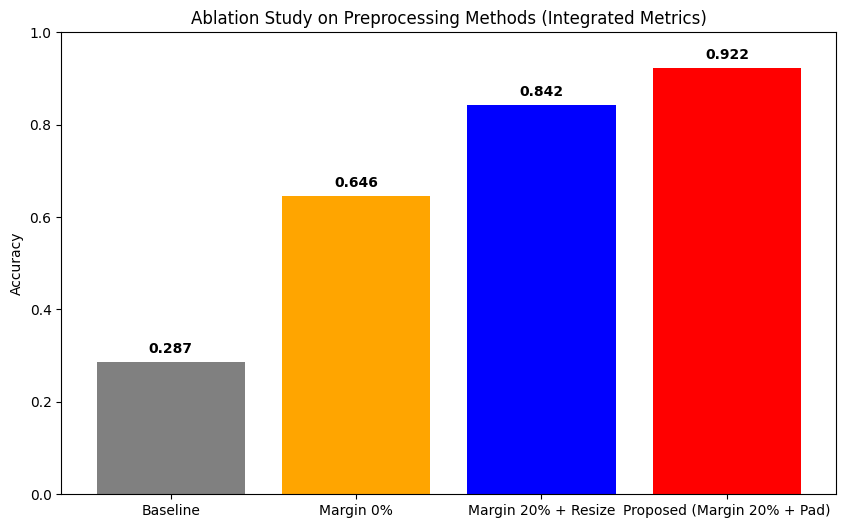

In [ ]:
import os
import glob
import json
import cv2
import torch
from PIL import Image
import torchvision.transforms as transforms
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# 검증용 파일 목록 가져오기 (전체 테스트 데이터 사용)
all_test_jsons = sorted(glob.glob('/content/llm_dataset/test/**/*.json', recursive=True))
sample_jsons_ablation = all_test_jsons

# 라벨 상태 매핑 딕셔너리
status_mapping = {
    '0_Normal': '정상',
    '1_Partial': '부분체결',
    '2_Missing': '미체결',
    '3_Error': '오류체결',
    '완전체결 상태': '정상',
    '부분체결 상태': '부분체결',
    '미체결 상태': '미체결',
    '오류체결 상태': '오류체결'
}

# Transform 정의
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def square_pad(pil_img):
    w, h = pil_img.size
    max_wh = max(w, h)
    padded = Image.new('RGB', (max_wh, max_wh), (0, 0, 0))
    padded.paste(pil_img, ((max_wh - w) // 2, (max_wh - h) // 2))
    return padded

# 결과 저장용
results = {
    'Baseline': {'gt': [], 'pred': []},
    'Crop_0': {'gt': [], 'pred': []},
    'Crop_20_Resize': {'gt': [], 'pred': []},
    'Crop_20_Pad': {'gt': [], 'pred': []}
}

print(f"Ablation Study 진행 중... 통합 테스트 방식 적용 (Missed/False Alarm 포함) (샘플 {len(sample_jsons_ablation)}개)")
for json_path in tqdm(sample_jsons_ablation):
    img_path = json_path.rsplit('.', 1)[0] + '.jpg'
    if not os.path.exists(img_path): continue

    # GT 로드
    with open(json_path, 'r', encoding='utf-8-sig') as f:
        data = json.load(f)

    gt_statuses = []
    for ann in data.get('Annotation', []):
        st = ann.get('Subclass_status')
        if st:
            gt_statuses.append(status_mapping.get(st, st))

    if not gt_statuses: continue

    orig_img_bgr = cv2.imread(img_path)
    if orig_img_bgr is None: continue
    orig_img_rgb = cv2.cvtColor(orig_img_bgr, cv2.COLOR_BGR2RGB)
    orig_pil = Image.fromarray(orig_img_rgb)

    # YOLO 추론 (객체 위치 파악)
    yolo_res = eval_model.predict(img_path, conf=0.5, imgsz=640, max_det=10, verbose=False)[0]
    boxes_data = yolo_res.boxes.data.cpu().numpy()

    # 1. Baseline: 원본 전체 추론 (이미지당 1번만 수행하여 효율성 확보)
    t_base = base_transform(orig_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        base_pred = resnet_classes[classification_model(t_base).argmax().item()]

    # 각 방식별 예측 결과 임시 저장
    preds_base = []
    preds_crop0 = []
    preds_crop20_res = []
    preds_crop20_pad = []

    # 탐지된 객체에 대해 검사 진행
    for row in boxes_data:
        x1, y1, x2, y2, conf, cls = row
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

        # 2. Crop 0%
        crop_0 = Image.fromarray(orig_img_rgb[y1:y2, x1:x2])
        t_crop_0 = base_transform(crop_0).unsqueeze(0).to(device) if crop_0.size[0]>0 and crop_0.size[1]>0 else t_base

        # 3. Crop 20% + 일반 Resize
        bw, bh = x2 - x1, y2 - y1
        mx, my = int(bw * 0.2), int(bh * 0.2)
        cx1, cy1 = max(0, x1 - mx), max(0, y1 - my)
        cx2, cy2 = min(orig_img_rgb.shape[1], x2 + mx), min(orig_img_rgb.shape[0], y2 + my)
        crop_20 = Image.fromarray(orig_img_rgb[cy1:cy2, cx1:cx2])
        t_crop_20_resize = base_transform(crop_20).unsqueeze(0).to(device) if crop_20.size[0]>0 and crop_20.size[1]>0 else t_base

        # 4. Crop 20% + SquarePad (제안 방식)
        t_crop_20_pad = base_transform(square_pad(crop_20)).unsqueeze(0).to(device) if crop_20.size[0]>0 and crop_20.size[1]>0 else t_base

        with torch.no_grad():
            preds_base.append(base_pred)
            preds_crop0.append(resnet_classes[classification_model(t_crop_0).argmax().item()])
            preds_crop20_res.append(resnet_classes[classification_model(t_crop_20_resize).argmax().item()])
            preds_crop20_pad.append(resnet_classes[classification_model(t_crop_20_pad).argmax().item()])

    # === 통합 성능 테스트와 완벽히 동일한 매칭/패널티 로직 ===
    gt_statuses.sort()
    preds_base.sort()
    preds_crop0.sort()
    preds_crop20_res.sort()
    preds_crop20_pad.sort()

    min_len = min(len(gt_statuses), len(boxes_data))

    def add_results(method_name, preds_list):
        results[method_name]['gt'].extend(gt_statuses[:min_len])
        results[method_name]['pred'].extend(preds_list[:min_len])

        # YOLO가 놓친 것(Missed) 패널티
        for gt in gt_statuses[min_len:]:
            results[method_name]['gt'].append(gt)
            results[method_name]['pred'].append('None(Missed)')

        # YOLO가 잘못 찾은 것(False Alarm) 패널티
        for p in preds_list[min_len:]:
            results[method_name]['gt'].append('None(False_Alarm)')
            results[method_name]['pred'].append(p)

    add_results('Baseline', preds_base)
    add_results('Crop_0', preds_crop0)
    add_results('Crop_20_Resize', preds_crop20_res)
    add_results('Crop_20_Pad', preds_crop20_pad)

# 결과 출력
print("\n=== Ablation Study 결과 (Accuracy - 통합 테스트 기준) ===")
for k in results:
    acc = accuracy_score(results[k]['gt'], results[k]['pred']) if len(results[k]['gt']) > 0 else 0
    print(f"- {k}: {acc:.4f}")

# 바 그래프 시각화
acc_scores = [accuracy_score(results[k]['gt'], results[k]['pred']) if len(results[k]['gt']) > 0 else 0 for k in results]
plt.figure(figsize=(10, 6))
plt.bar(['Baseline', 'Margin 0%', 'Margin 20% + Resize', 'Proposed (Margin 20% + Pad)'], acc_scores, color=['gray', 'orange', 'blue', 'red'])
plt.title('Ablation Study on Preprocessing Methods (Integrated Metrics)')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)
for i, v in enumerate(acc_scores):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.show()


# 시각화 및 출력 결과 확인

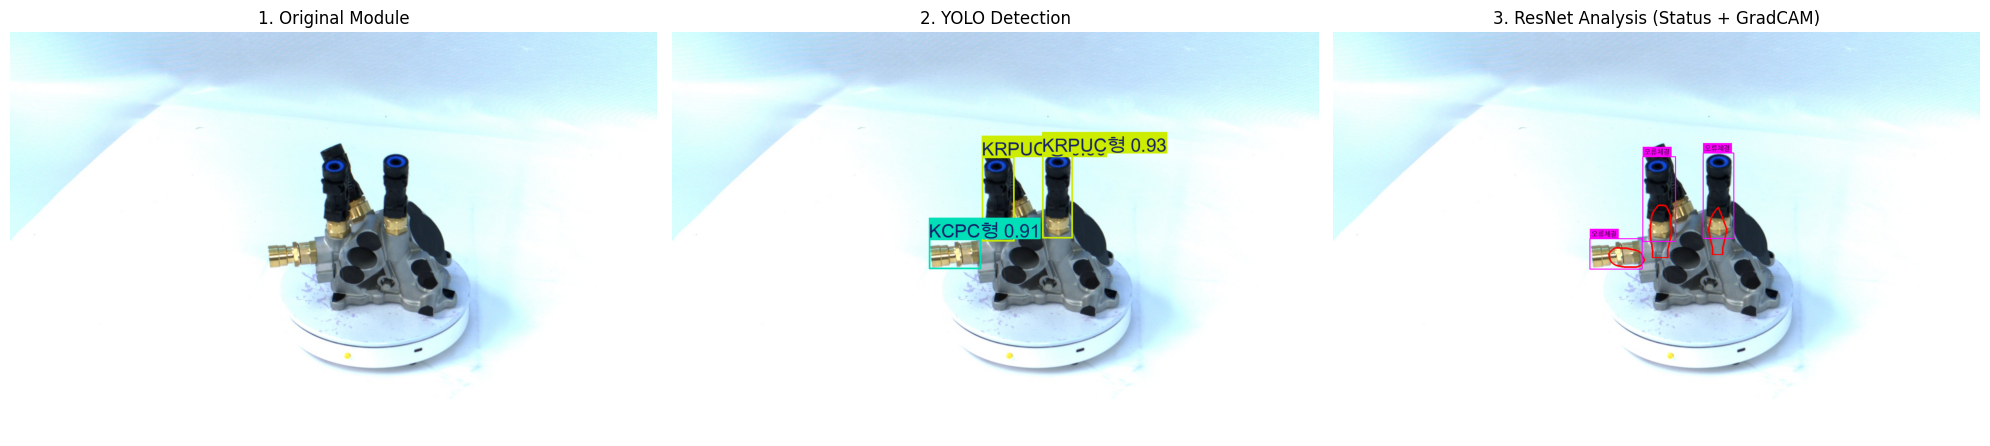

--- 검출 및 진단 결과 ---
[
  {
    "part_name": "KRPUC형",
    "status": "오류체결",
    "yolo_confidence": 0.9307727217674255,
    "resnet_confidence": 0.999534010887146
  },
  {
    "part_name": "KCPC형",
    "status": "오류체결",
    "yolo_confidence": 0.9085363745689392,
    "resnet_confidence": 0.999915599822998
  },
  {
    "part_name": "KRPUC형",
    "status": "오류체결",
    "yolo_confidence": 0.8981748223304749,
    "resnet_confidence": 0.9999991655349731
  }
]




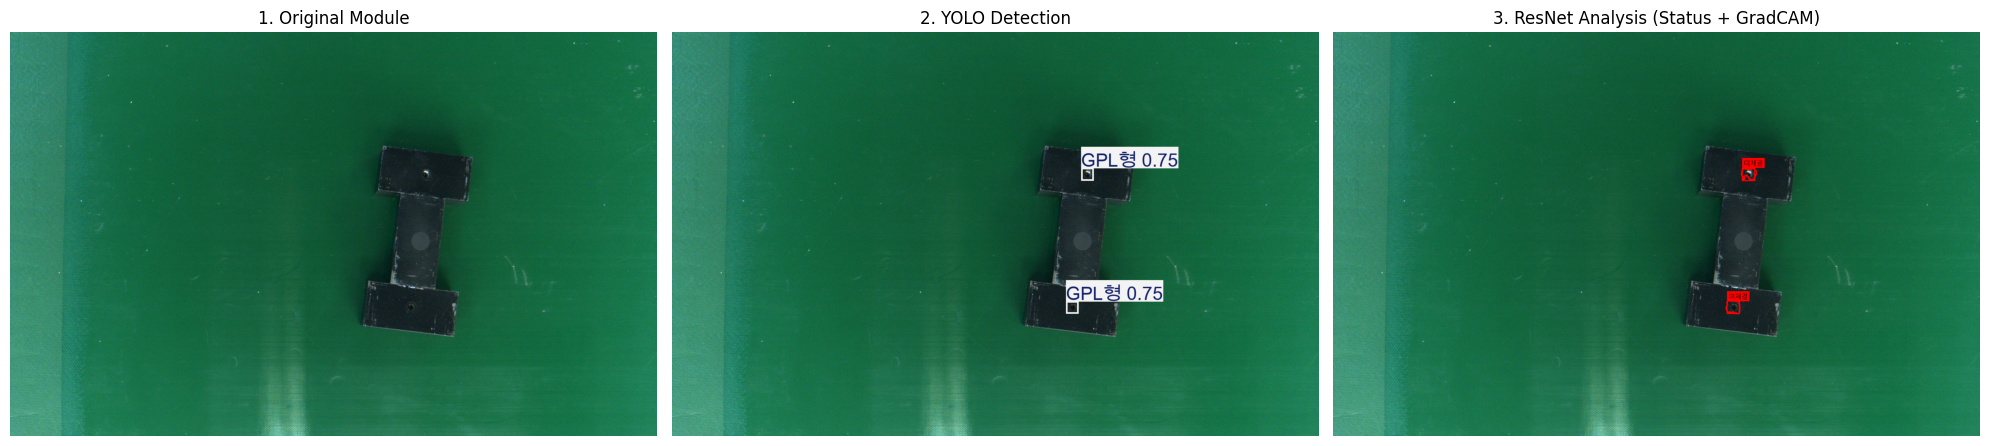

--- 검출 및 진단 결과 ---
[
  {
    "part_name": "GPL형",
    "status": "미체결",
    "yolo_confidence": 0.7510509490966797,
    "resnet_confidence": 1.0
  },
  {
    "part_name": "GPL형",
    "status": "미체결",
    "yolo_confidence": 0.7469744086265564,
    "resnet_confidence": 1.0
  }
]




In [ ]:
import os
import glob
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import urllib.request
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
import json

# ==========================================
# 0. 한글 폰트 다운로드 (cv2 한글 깨짐 방지)
# ==========================================
font_path = 'NanumGothic.ttf'

if not os.path.exists(font_path):
    urllib.request.urlretrieve("https://hangeul.pstatic.net/hangeul_static/webfont/NanumGothic/NanumGothic.ttf", font_path)

# ==========================================
# 1. 환경 설정 및 기존 로드된 모델 재사용
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# (이전 셀 cb1efc3f 에서 classification_model 과 eval_model이 이미 로드되어 있어야 합니다.)

# ==========================================
# 2. Grad-CAM 타겟 레이어 및 Transform 설정
# ==========================================
# AssemblyResNet 내부에 있는 resnet18(self.model)의 layer4 마지막 블록을 타겟으로 설정
target_layers = [classification_model.model.layer4[-1]]

transform_val = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

resnet_classes = ['정상', '부분체결', '미체결', '오류체결']

# ==========================================
# 3. 통합 파이프라인 함수 정의 (Standard ResNet)
# ==========================================
def run_integrated_pipeline(img_path, yolo_model, resnet_model, cam_target_layers):
    orig_img_bgr = cv2.imread(img_path)
    if orig_img_bgr is None:
        print(f"이미지를 읽을 수 없습니다: {img_path}")
        return None, None

    orig_img_rgb = cv2.cvtColor(orig_img_bgr, cv2.COLOR_BGR2RGB)

    # YOLO 탐지
    yolo_results = yolo_model.predict(img_path, conf=0.5, agnostic_nms=False, verbose=False)[0]

    # 레퍼런스 이미지가 없으므로 3개의 subplot으로 구성
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    axes[0].imshow(orig_img_rgb)
    axes[0].set_title("1. Original Module")
    axes[0].axis('off')

    img_yolo = yolo_results.plot()
    img_yolo_rgb = cv2.cvtColor(img_yolo, cv2.COLOR_BGR2RGB)
    axes[1].imshow(img_yolo_rgb)
    axes[1].set_title("2. YOLO Detection")
    axes[1].axis('off')

    analysis_viz = orig_img_rgb.copy()
    boxes_data = yolo_results.boxes.data.cpu().numpy()

    report_results = []

    # GradCAM 객체 생성
    cam_obj = GradCAM(model=resnet_model, target_layers=cam_target_layers)

    for row in boxes_data:
        x1, y1, x2, y2, conf, cls = row
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        yolo_class_name = yolo_results.names[int(cls)]

        bw, bh = x2 - x1, y2 - y1
        mx, my = int(bw * 0.2), int(bh * 0.2)

        cx1, cy1 = max(0, x1 - mx), max(0, y1 - my)
        cx2, cy2 = min(orig_img_rgb.shape[1], x2 + mx), min(orig_img_rgb.shape[0], y2 + my)

        crop_pil = Image.fromarray(orig_img_rgb[cy1:cy2, cx1:cx2])

        w, h = crop_pil.size
        max_wh = max(w, h)
        padded = Image.new('RGB', (max_wh, max_wh), (0, 0, 0))
        padded.paste(crop_pil, ((max_wh - w) // 2, (max_wh - h) // 2))
        input_tensor = transform_val(padded.resize((224, 224))).unsqueeze(0).to(device)

        # Standard ResNet Inference
        with torch.no_grad():
            outputs = resnet_model(input_tensor)
            probabilities = F.softmax(outputs, dim=1)
            best_conf, best_pred_idx_tensor = probabilities.max(dim=1)
            best_conf = best_conf.item()
            best_pred_idx = best_pred_idx_tensor.item()

        label_text = resnet_classes[best_pred_idx]

        report_results.append({
            "part_name": yolo_class_name,
            "status": label_text,
            "yolo_confidence": float(conf),
            "resnet_confidence": float(best_conf)
        })

        if best_pred_idx != 0:
            # 정상(0)이 아닐 때만 Grad-CAM 적용
            targets = [ClassifierOutputTarget(best_pred_idx)]
            grayscale_cam = cam_obj(input_tensor=input_tensor, targets=targets)[0, :]
            mask = (grayscale_cam > 0.5).astype(np.uint8) * 255
            mask_resized = cv2.resize(mask, (cx2 - cx1, cy2 - cy1))

            crop_np = orig_img_rgb[cy1:cy2, cx1:cx2]
            padding_filter = np.all(crop_np < 10, axis=-1)
            mask_resized[padding_filter] = 0

            contours, _ = cv2.findContours(mask_resized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            cv2.drawContours(analysis_viz[cy1:cy2, cx1:cx2], contours, -1, (255, 0, 0), 3)

        color_map = {0: (0, 255, 0), 1: (255, 165, 0), 2: (255, 0, 0), 3: (255, 0, 255)}
        class_color = color_map.get(best_pred_idx, (255, 0, 0))

        cv2.rectangle(analysis_viz, (x1, y1), (x2, y2), class_color, 2)

        pil_img_for_text = Image.fromarray(analysis_viz)
        draw = ImageDraw.Draw(pil_img_for_text)
        korean_font = ImageFont.truetype(font_path, 20)

        bbox = draw.textbbox((0, 0), label_text, font=korean_font)
        text_w = bbox[2] - bbox[0]
        text_h = bbox[3] - bbox[1]

        draw.rectangle([(x1, y1 - text_h - 10), (x1 + text_w + 10, y1)], fill=class_color)
        draw.text((x1 + 5, y1 - text_h - 7), label_text, font=korean_font, fill=(0, 0, 0))

        analysis_viz = np.array(pil_img_for_text)

    axes[2].imshow(analysis_viz)
    axes[2].set_title("3. ResNet Analysis (Status + GradCAM)")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return report_results, analysis_viz

# ==========================================
# 4. 테스트 실행
# ==========================================
test_images = glob.glob('/content/llm_dataset/test/**/*.jpg', recursive=True)
if test_images:
    num_samples = min(2, len(test_images))
    sampled_test = random.sample(test_images, num_samples)
    for path in sampled_test:
        results, final_img = run_integrated_pipeline(path, eval_model, classification_model, target_layers)
        print("--- 검출 및 진단 결과 ---")
        print(json.dumps(results, indent=2, ensure_ascii=False))
        print("\n")


# 학습 JSON 파일로 RAG 지식 DB 구축하기
`train` 폴더의 JSON 라벨 데이터를 읽어와 SQLite DB(`maintenance.db`)를 생성합니다.

In [ ]:
import os
import glob
import json
import sqlite3

# 새롭게 생성할 로컬 DB 경로
DB_PATH = '/content/maintenance.db'

def build_maintenance_db(json_folder='/content/llm_dataset/train'):
    json_files = glob.glob(f"{json_folder}/**/*.json", recursive=True)

    if not json_files:
        print(f"'{json_folder}' 경로에 JSON 파일이 없습니다. 훈련 데이터를 먼저 압축 해제해주세요!")
        return

    conn = sqlite3.connect(DB_PATH)
    cursor = conn.cursor()

    # 지식 DB 테이블 생성
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS maintenance_kb (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            part_type TEXT,
            subclass_status TEXT,
            action TEXT
        )
    ''')

    # 기존 데이터 초기화 (재실행 시 중복 방지)
    cursor.execute('DELETE FROM maintenance_kb')

    count = 0
    for jp in json_files:
        try:
            with open(jp, 'r', encoding='utf-8-sig') as f:
                data = json.load(f)

            # Annotation 내부의 부품, 상태, 조치(Action) 정보 추출
            for ann in data.get('Annotation', []):
                part_type = ann.get('Annotation_part_type')
                status = ann.get('Subclass_status')
                action = ann.get('Action')

                # 결측치 방지 및 조치 데이터가 존재하는 경우만 삽입
                if part_type and status and action and str(action).strip() != "None":
                    cursor.execute('''
                        INSERT INTO maintenance_kb (part_type, subclass_status, action)
                        VALUES (?, ?, ?)
                    ''', (part_type, status, action))
                    count += 1
        except Exception as e:
            print(f"파일 읽기 오류 ({jp}): {e}")

    conn.commit()
    conn.close()
    print(f"RAG DB 구축 완료! 총 {count}건의 조치 이력이 '{DB_PATH}'에 저장되었습니다.")

# DB 구축 실행
build_maintenance_db('/content/llm_dataset/train')

# 기존에 선언된 query_maintenance_db 함수가 새로운 로컬 DB_PATH를 참조하도록 덮어쓰기
def query_maintenance_db(part_name, status):
    if not os.path.exists(DB_PATH):
        return "DB 파일을 찾을 수 없습니다."
    try:
        conn = sqlite3.connect(DB_PATH)
        # '2_Missing' 등에서 텍스트 부분만 추출하여 유연하게 검색
        status_clean = status.split('_')[-1] if '_' in status else status

        query = """
            SELECT action FROM maintenance_kb
            WHERE part_type=? AND subclass_status LIKE ?
            LIMIT 5
        """
        rows = conn.execute(query, (part_name, f"%{status_clean}%")).fetchall()
        conn.close()

        if rows:
            # 중복 조치 내용 제거 후 반환
            unique_actions = list(set([r[0] for r in rows]))
            return unique_actions
        return "과거 조치 이력이 없습니다."
    except Exception as e:
        return f"DB 조회 오류: {e}"


RAG DB 구축 완료! 총 543101건의 조치 이력이 '/content/maintenance.db'에 저장되었습니다.


# Vector DB (ChromaDB) 초기화 및 데이터 임베딩
기존 SQLite에 저장된 조치 이력을 Sentence-Transformers를 이용해 벡터화하여 ChromaDB에 적재합니다.

In [ ]:
import sqlite3
import chromadb
from chromadb.utils import embedding_functions
from tqdm.auto import tqdm

print("ChromaDB 초기화 및 SentenceTransformer 임베딩 로드 중...")
chroma_client = chromadb.PersistentClient(path="/content/chroma_db")

# 원본 노트북과 동일한 임베딩 모델 사용
emb_fn = embedding_functions.SentenceTransformerEmbeddingFunction(
    model_name="jhgan/ko-sroberta-multitask"
)

collection = chroma_client.get_or_create_collection(
    name="assembly_maintenance_vectors",
    embedding_function=emb_fn,
    # ✨ 이 한 줄을 추가하여 코사인 유사도를 명시적으로 강제합니다!
    metadata={"hnsw:space": "cosine"}
)

# SQLite DB에서 데이터 불러오기
conn = sqlite3.connect('/content/maintenance.db')
rows = conn.execute("SELECT part_type, subclass_status, action FROM maintenance_kb").fetchall()
conn.close()

if collection.count() == 0 and rows:
    # 중복 제거를 통해 핵심 조치 방법들만 임베딩 (성능 최적화)
    unique_rows = list(set([(r[0], r[1], r[2]) for r in rows if str(r[2]).strip() != 'None']))

    print(f"총 {len(unique_rows)}개의 고유 조치 이력을 벡터 DB에 인덱싱합니다. (최초 1회 소요)")
    ids = []
    documents = []
    metadatas = []

    for i, (p_type, status, action) in enumerate(tqdm(unique_rows)):
        ids.append(str(i))
        # 검색 대상(Symptom)을 문서로 저장
        documents.append(f"{p_type} {status}")
        metadatas.append({
            "part_type": p_type,
            "subclass_status": status,
            "action": action
        })

    # 배치 사이즈 단위로 분할하여 업서트 (ChromaDB 제한 방지)
    batch_size = 5000
    for i in range(0, len(ids), batch_size):
        collection.upsert(
            ids=ids[i:i+batch_size],
            documents=documents[i:i+batch_size],
            metadatas=metadatas[i:i+batch_size]
        )
    print("✅ 벡터 DB 인덱싱 완료!")
else:
    print(f"✅ 벡터 DB가 이미 준비되어 있습니다. (현재 벡터 문서 수: {collection.count()})")

ChromaDB 초기화 및 SentenceTransformer 임베딩 로드 중...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.86k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

총 72개의 고유 조치 이력을 벡터 DB에 인덱싱합니다. (최초 1회 소요)


  0%|          | 0/72 [00:00<?, ?it/s]

✅ 벡터 DB 인덱싱 완료!


# Vector RAG 검색 및 통합 리포트 함수 정의
Vector DB 검색 함수 및 근본 원인 분석(Root Cause) 함수를 통합하여 파이프라인을 고도화합니다.

In [ ]:
import sqlite3
import json
from PIL import Image

# ==========================================
# 단계 9-1: 사고 로그(Incident Log) DB 초기화
# ==========================================
def init_incident_log_db():
    conn = sqlite3.connect('/content/maintenance.db')
    conn.execute('''
        CREATE TABLE IF NOT EXISTS incident_log (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
            part_name TEXT,
            status TEXT
        )
    ''')
    conn.commit()
    conn.close()

init_incident_log_db()

def log_incident(part_name, status):
    """단계 9-1: 사고 로그 축적 (INSERT)"""
    conn = sqlite3.connect('/content/maintenance.db')
    conn.execute("INSERT INTO incident_log (part_name, status) VALUES (?, ?)", (part_name, status))
    conn.commit()
    conn.close()

def check_repetition(part_name, status, threshold=2):
    """단계 9-2①: 통계적 반복 감지 (GROUP BY + HAVING)"""
    conn = sqlite3.connect('/content/maintenance.db')

    # 기획안에 맞춰 GROUP BY와 HAVING을 사용한 통계적 검사 쿼리
    query = """
        SELECT part_name, status, COUNT(*) as cnt
        FROM incident_log
        GROUP BY part_name, status
        HAVING cnt >= ? AND part_name = ? AND status = ?
    """
    row = conn.execute(query, (threshold, part_name, status)).fetchone()

    # 단순 누적 발생 횟수 표시를 위한 전체 카운트
    total_count = conn.execute("SELECT COUNT(*) FROM incident_log WHERE part_name=? AND status=?", (part_name, status)).fetchone()[0]
    conn.close()

    if row:
        return f"🚨 [반복 경고] 해당 불량은 누적 {total_count}회 발생하여 통계적 반복 기준치({threshold}회)를 초과했습니다! 고질적인 공정 문제일 수 있습니다."
    else:
        return f"누적 발생 횟수: {total_count}회 (기준치 미달, 우발적 불량으로 추정)"

# ==========================================
# Vector RAG 검색 로직
# ==========================================
def query_vector_db(part_name, status, top_k=3):
    """ChromaDB를 이용한 의미론적 벡터 유사도 검색"""
    query_text = f"{part_name} {status}"

    if 'collection' not in globals():
        return ["벡터 DB(ChromaDB)가 로드되지 않았습니다."]

    results = collection.query(
        query_texts=[query_text],
        n_results=top_k
    )

    actions = []
    if results['distances'] and results['distances'][0]:
        for meta in results['metadatas'][0]:
            actions.append(meta['action'])

    if actions:
        return list(set(actions))
    return ["유사한 과거 조치 이력을 찾지 못했습니다."]

print("✅ RAG 검색 및 사고 로그 함수 정의 완료 (이후 단계에서 Gemini LLM과 연동되어 통합 리포트를 생성합니다)")

✅ RAG 검색 및 사고 로그 함수 정의 완료 (이후 단계에서 Gemini LLM과 연동되어 통합 리포트를 생성합니다)


# Gemini 기반 리포트 생성 함수

In [ ]:
import json
import google.generativeai as genai
from google.colab import userdata
from PIL import Image

print("코 LLM 모데ᄅ을 Gemini(3.5-flash)로 변경함니다...")

# Gemini API 설정
try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
except userdata.SecretNotFoundError:
    print("이 API 키를 차즐 수 없습니다. Colab 왼쪽 열쇠 아이콘(Secrets)에 GOOGLE_API_KEY를 추가해주세요.")

# 모데ᄅ 설정 (gemini-3.5-flash 사용)
gemini_model = genai.GenerativeModel('models/gemini-3.5-flash')

def generate_final_report_gemini(image_array, diagnosis_results):
    """Gemini를 활용한 통합 최종 리포트 생성 시 근본 원인 분석"""
    pil_img = Image.fromarray(image_array)

    rag_context = ""
    incident_stats_context = ""
    has_anomaly = False

    for item in diagnosis_results:
        if item['status'] != '정상':
            has_anomaly = True
            log_incident(item['part_name'], item['status'])

            repetition_info = check_repetition(item['part_name'], item['status'])
            incident_stats_context += f"- 부품: {item['part_name']}, 상태: {item['status']}\n  통계 분석: {repetition_info}\n\n"

            actions = query_vector_db(item['part_name'], item['status'])
            rag_context += f"- 부품: {item['part_name']}, 상태: {item['status']}\n  유사 조치 이력: {actions}\n\n"

    if not has_anomaly:
        return "불량이 발견되지 아납습니다. 모든 상태가 정상입니다."

    prompt = f"""
    당신은 제조 공정의 스마트 팩토리 비전 검사 AI 어시스턴트입니다.
    아래 제공된 [현재 상태], [통계적 반복 발생 여부], [권장 조치 방안(RAG 검색 결과)]를 종합하여,
    불량의 근본 원인 분석(Root Cause Analysis)과 최종 조치 권고사항이 포함된 상세한 리포트를 작성해주세요.

    [현재 상태 미ᄎ 발견된 문제점]
    {json.dumps(diagnosis_results, ensure_ascii=False, indent=2)}

    [통계적 반복 발생 여부 (사고 로그)]
    {incident_stats_context.strip()}

    [권장 조치 방안 (Vector RAG 기반 DB 검색)]
    {rag_context.strip()}

    리포트는 마크다운 형식으로 작성해주시고, 제공된 이미지를 참고하여 체계적으로 분석해주세요.
    """

    try:
        # 이미지와 텍스트 프롬프트를 함께 전송 (Multimodal)
        response = gemini_model.generate_content([prompt, pil_img])
        return response.text
    except Exception as e:
        # 에러를 문자열로 반환하지 않고 Exception을 그대로 발생시켜서 wrapper의 재시도 로직이 작동하게 합니다.
        raise e

# 기존 리포트 생성 함수를 Gemini 버전으로 더퍼쓰기
# generate_final_report = generate_final_report_gemini
# generate_final_report_v2 = generate_final_report_gemini

print("✅ LLM 모데리 gemini-3.5-flash 로 성공적으로 설정되없습니다! (에러 재시도 로직 수정됨)")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


코 LLM 모데ᄅ을 Gemini(3.5-flash)로 변경함니다...
✅ LLM 모데리 gemini-3.5-flash 로 성공적으로 설정되없습니다! (에러 재시도 로직 수정됨)


In [ ]:
from PIL import Image, ImageDraw, ImageFont
import textwrap
import os

# 1. 비전 검사 이미지 로드
img_to_save = Image.fromarray(final_img)

# 2. 리포트 텍스트를 그리기 위한 폰트 설정 (이전 셀의 나눔고딕 재사용)
font_path = 'NanumGothic.ttf'
try:
    font = ImageFont.truetype(font_path, 20)
except:
    font = ImageFont.load_default()
    print("경고: 폰트를 불러올 수 없어 한글이 깨질 수 있습니다.")

# 3. 텍스트 줄바꿈 (가로 길이에 맞게)
wrapped_lines = []
for line in report.split('\n'):
    if line.strip() == "":
        wrapped_lines.append("")
    else:
        # 한 줄당 약 80글자 제한
        wrapped_lines.extend(textwrap.wrap(line, width=80))

# 4. 텍스트 영역 이미지 크기 계산
line_height = 25
text_height = len(wrapped_lines) * line_height + 40
text_width = max(img_to_save.width, 1000) # 최소 너비 보장

# 5. 텍스트 캔버스 생성 및 그리기
text_img = Image.new('RGB', (text_width, text_height), color=(255, 255, 255))
draw = ImageDraw.Draw(text_img)

y_text = 20
for line in wrapped_lines:
    draw.text((20, y_text), line, font=font, fill=(0, 0, 0))
    y_text += line_height

# 6. 원본 이미지와 텍스트 이미지 병합 (위: 사진, 아래: 텍스트)
total_width = max(img_to_save.width, text_img.width)
total_height = img_to_save.height + text_img.height

combined_img = Image.new('RGB', (total_width, total_height), (255, 255, 255))
combined_img.paste(img_to_save, ((total_width - img_to_save.width) // 2, 0))
combined_img.paste(text_img, (0, img_to_save.height))

# 7. 최종 저장
save_path = '/content/final_report_full.jpg'
combined_img.save(save_path)
print(f"\u2705 사진과 리포트가 통합된 이미지가 성공적으로 저장되었습니다: {save_path}")

# (선택) 다운로드
# from google.colab import files
# files.download(save_path)

✅ 사진과 리포트가 통합된 이미지가 성공적으로 저장되었습니다: /content/final_report_full.jpg


In [ ]:
import base64
from io import BytesIO
from PIL import Image
import markdown # 마크다운을 HTML로 변환하기 위한 라이브러리

# 1. 비전 검사 이미지를 Base64 문자열로 변환 (HTML 내장용)
img_pil = Image.fromarray(final_img)
buffered = BytesIO()
img_pil.save(buffered, format="JPEG")
img_str = base64.b64encode(buffered.getvalue()).decode('utf-8')

# 2. 마크다운 리포트 텍스트를 HTML 코드로 변환 (표 서식 등 유지)
html_text = markdown.markdown(report, extensions=['tables', 'fenced_code'])

# 3. 코랩 셀 출력과 유사한 스타일을 적용한 HTML 템플릿 생성
html_content = f"""
<!DOCTYPE html>
<html lang="ko">
<head>
    <meta charset="UTF-8">
    <style>
        body {{
            font-family: 'NanumGothic', 'Malgun Gothic', sans-serif;
            line-height: 1.6;
            padding: 40px;
            max-width: 1200px;
            margin: auto;
            color: #333;
        }}
        .image-container {{
            text-align: center;
            margin-bottom: 30px;
        }}
        img {{
            max-width: 100%;
            height: auto;
            border: 1px solid #ddd;
            border-radius: 8px;
            box-shadow: 0 4px 8px rgba(0,0,0,0.1);
        }}
        table {{
            border-collapse: collapse;
            width: 100%;
            margin-top: 15px;
            margin-bottom: 25px;
        }}
        th, td {{
            border: 1px solid #ddd;
            padding: 10px;
            text-align: left;
        }}
        th {{
            background-color: #f4f6f8;
        }}
        h1, h2, h3 {{
            color: #202124;
            border-bottom: 1px solid #eee;
            padding-bottom: 8px;
            margin-top: 30px;
        }}
    </style>
</head>
<body>
    <div class="image-container">
        <img src="data:image/jpeg;base64,{img_str}" alt="Vision Inspection Result">
    </div>
    <div class="report-container">
        {html_text}
    </div>
</body>
</html>
"""

# 4. HTML 파일로 저장
save_path_html = '/content/final_report_styled.html'
with open(save_path_html, 'w', encoding='utf-8') as f:
    f.write(html_content)

print(f"\u2705 서식이 유지된 리포트(HTML)가 성공적으로 저장되었습니다: {save_path_html}")
print("왼쪽 폴더 아이콘을 눌러 파일을 다운로드한 뒤 브라우저에서 열어보세요!")

# (선택) 바로 다운로드
# from google.colab import files
# files.download(save_path_html)

✅ 서식이 유지된 리포트(HTML)가 성공적으로 저장되었습니다: /content/final_report_styled.html
왼쪽 폴더 아이콘을 눌러 파일을 다운로드한 뒤 브라우저에서 열어보세요!


```markdown
### 📊 RAGAS 평가 라이브러리 설치
리포트 생성 직후 신뢰도를 평가하기 위해 `ragas`와 `langchain-google-genai`를 설치합니다.
```

In [ ]:
print('Installing zstd...')
!sudo apt-get update && sudo apt-get install -y zstd

Installing zstd...
Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,578 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,908 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,164 kB]
Get:9 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [108 kB]
Get:13 http://archive.ubuntu.com/ubuntu 

In [ ]:
print('Installing langchain-ollama...')
!pip install langchain-ollama -q

Installing langchain-ollama...


In [ ]:
!pip install "ragas==0.3.9" langchain langchain-community langchain-core langchain-google-genai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.7/366.7 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.3/73.3 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.0/567.0 kB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.5/252.5 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.7/123.7 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 137.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 353.9/353.9 kB 37.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the 

In [ ]:
!pip install -U langchain-google-genai -q

```markdown
### 🔄 통합 리포트 함수 업데이트 (RAGAS 점수 포함)
기존 리포트 생성 함수를 래핑(Wrapping)하여, 리포트가 생성되자마자 RAGAS로 평가하고 그 결과를 리포트 하단에 추가하도록 수정합니다.
```

In [ ]:
# Gemini 리포트 생성을 건너뛰고 RAGAS 평가만 출력하려면 True로 설정하세요.
# Gemini 리포트를 포함하려면 False로 설정하세요.
SKIP_GEMINI_REPORT = True

In [ ]:
import os
import sys, types
import math
import time

# ragas가 찾는 옛날 경로를 가짜로 만들어서 import 에러를 우회
fake_module = types.ModuleType("langchain_community.chat_models.vertexai")
class ChatVertexAI:
    pass
fake_module.ChatVertexAI = ChatVertexAI
sys.modules["langchain_community.chat_models.vertexai"] = fake_module

# 이제 ragas import
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.run_config import RunConfig
import warnings
warnings.filterwarnings('ignore')

# RAGAS 평가용 기본 LLM 및 임베딩 모델 설정 (Gemini 활용)
base_llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    google_api_key=GOOGLE_API_KEY,
    request_timeout=120,
    max_retries=5
)
base_embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=GOOGLE_API_KEY
)

# ✨ 최신 RAGAS 규격에 맞게 래퍼(Wrapper) 씌우기
ragas_llm = LangchainLLMWrapper(base_llm)
ragas_embeddings = LangchainEmbeddingsWrapper(base_embeddings)

# 후보 여러 개(candidateCount>1)를 요청하지 않도록 1로 고정
answer_relevancy.strictness = 1

# RAGAS 실행 설정
run_config = RunConfig(timeout=180, max_retries=10, max_workers=1)


# ------------------------------------------------------------------
# 429(quota exceeded)를 만나면 대기 후 재시도하는 범용 wrapper
# ------------------------------------------------------------------
def call_with_retry(func, *args, max_attempts=6, base_wait=30, label="호출", **kwargs):
    for attempt in range(max_attempts):
        try:
            return func(*args, **kwargs)
        except Exception as e:
            err_str = str(e)
            if "429" in err_str or "quota" in err_str.lower() or "RESOURCE_EXHAUSTED" in err_str:
                wait = base_wait * (attempt + 1)
                print(f"⏳ [{label}] Quota 초과, {wait}초 대기 후 재시도 ({attempt + 1}/{max_attempts})...")
                time.sleep(wait)
            else:
                # quota 문제가 아닌 다른 에러는 즉시 올려보냄
                raise
    raise RuntimeError(f"[{label}] 재시도 한도({max_attempts}회)를 초과했습니다. quota 문제가 지속되고 있습니다.")


def generate_report_with_ragas(image_array, diagnosis_results):
    # 1. 기존 함수를 호출하여 기본 리포트 텍스트 생성 (429 재시도 적용)
    print("1️⃣ Gemini가 상황을 분석하여 리포트를 작성 중입니다...")
    base_report = call_with_retry(
        generate_final_report_gemini,
        image_array,
        diagnosis_results,
        label="리포트 생성"
    )

    # 불량이 없으면 평가 제외
    if "불량이 발견되지 않았습니다" in base_report:
        return base_report

    # 리포트 생성 호출과 RAGAS 평가 호출 사이 쿨다운 (quota 회복 대기)
    time.sleep(40)

    # 2. RAGAS 평가를 위한 Context(참조 문서) 추출
    contexts = []
    for item in diagnosis_results:
        if item['status'] != '정상':
            actions = query_vector_db(item['part_name'], item['status'])
            contexts.extend(actions)

    contexts = list(set([str(c) for c in contexts]))
    if not contexts:
        contexts = ["참조할 과거 이력이 없습니다."]

    # 3. 최신 RAGAS 0.3.x 입력용 데이터셋(HuggingFace Dataset 포맷) 생성
    question = "발견된 불량 상태와 과거 조치 이력을 바탕으로 근본 원인과 조치 권고사항을 상세히 작성해."
    data = {
        "user_input": [question],
        "response": [base_report],
        "retrieved_contexts": [contexts]
    }
    dataset = Dataset.from_dict(data)

    # 4. RAGAS 지표 계산 (429 재시도 적용)
    print("2️⃣ 작성된 리포트의 신뢰도를 RAGAS로 검증 중입니다 (quota 재시도 로직 적용, 시간이 걸릴 수 있습니다)...")
    try:
        score = call_with_retry(
            evaluate,
            dataset,
            metrics=[faithfulness, answer_relevancy],
            llm=ragas_llm,
            embeddings=ragas_embeddings,
            run_config=run_config,
            raise_exceptions=True,
            label="RAGAS 평가",
            base_wait=35
        )

        # 5. 최종 리포트에 평가 결과 병합
        df_score = score.to_pandas()

        f_score = float(df_score["faithfulness"].iloc[0]) if "faithfulness" in df_score.columns else 0.0
        ar_score = float(df_score["answer_relevancy"].iloc[0]) if "answer_relevancy" in df_score.columns else 0.0

        if math.isnan(f_score): f_score = 0.0
        if math.isnan(ar_score): ar_score = 0.0

        ragas_section = f"\n\n---\n## 📊 RAGAS 신뢰도 평가 결과\n"
        ragas_section += f"- **충실성 (Faithfulness):** `{f_score:.3f}` (검색된 과거 이력을 환각 없이 얼마나 잘 반영했는가)\n"
        ragas_section += f"- **답변 관련성 (Answer Relevancy):** `{ar_score:.3f}` (불량 상황 해결에 얼마나 직관적이고 유용한 답변인가)\n"

        if f_score == 0.0 and ar_score == 0.0:
            ragas_section += "\n*(주의: 평가 점수가 0점인 경우, RAGAS 평가 중 Gemini API 서버 과부하 또는 타임아웃이 발생하여 점수가 측정되지 않았을 확률이 높습니다.)*\n"

        return base_report + ragas_section

    except Exception as e:
        print(f"RAGAS 평가 중 오류 발생: {e}")
        return base_report + f"\n\n---\n*RAGAS 평가를 수행하지 못했습니다: {e}*"


# 전역 함수 덮어쓰기
generate_final_report = generate_report_with_ragas
print("✅ Quota(429) 재시도 로직을 추가하여 파이프라인을 고도화했습니다!")
print("이제 위쪽의 '[최종 테스트] 비전 검사 및 Gemini 유지보수 리포트 생성' 셀을 다시 실행해보세요.")

✅ Quota(429) 재시도 로직을 추가하여 파이프라인을 고도화했습니다!
이제 위쪽의 '[최종 테스트] 비전 검사 및 Gemini 유지보수 리포트 생성' 셀을 다시 실행해보세요.


# RAGAS 평가용 코드

In [ ]:
import os
import sys, types
import math
import time

# ragas가 찾는 옛날 경로를 가짜로 만들어서 import 에러를 우회
fake_module = types.ModuleType("langchain_community.chat_models.vertexai")
class ChatVertexAI:
    pass
fake_module.ChatVertexAI = ChatVertexAI
sys.modules["langchain_community.chat_models.vertexai"] = fake_module

# Install langchain-huggingface if not already installed
!pip install langchain-huggingface -q

# 이제 ragas import
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy
from langchain_google_genai import ChatGoogleGenerativeAI  # 리포트 생성용 (Gemini 유지)
from langchain_ollama import ChatOllama                     # RAGAS 평가용 (로컬 LLM)
from langchain_huggingface import HuggingFaceEmbeddings     # RAGAS 평가용 (로컬 임베딩)
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from ragas.run_config import RunConfig
import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------
# RAGAS 평가 전용: 로컬 LLM / 로컬 임베딩 (quota 없음, 무료)
# 사용자가 요청한 LLaVA 모델로 변경합니다.
# ------------------------------------------------------------------
local_judge_llm = ChatOllama(model="llama3.1", temperature=0)   # 👈 llava → llama3.1로 변경
local_embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

ragas_llm = LangchainLLMWrapper(local_judge_llm)
ragas_embeddings = LangchainEmbeddingsWrapper(local_embeddings)

# 후보 여러 개(candidateCount>1) 관련 이슈는 로컬 모델엔 해당 없지만 그대로 유지
answer_relevancy.strictness = 1

# RAGAS 실행 설정 (로컬 모델은 quota가 없으니 재시도 횟수는 낮춰도 무방)
run_config = RunConfig(timeout=180, max_retries=3, max_workers=1)


# ------------------------------------------------------------------
# 429(quota exceeded)를 만나면 대기 후 재시도하는 wrapper
# → 이제 리포트 생성(Gemini)에만 필요, RAGAS 평가에는 불필요
# ------------------------------------------------------------------
def call_with_retry(func, *args, max_attempts=6, base_wait=30, label="호출", **kwargs):
    for attempt in range(max_attempts):
        try:
            return func(*args, **kwargs)
        except Exception as e:
            err_str = str(e)
            if "429" in err_str or "quota" in err_str.lower() or "RESOURCE_EXHAUSTED" in err_str:
                wait = base_wait * (attempt + 1)
                print(f"⏳ [{label}] Quota 초과, {wait}초 대기 후 재시도 ({attempt + 1}/{max_attempts})...")
                time.sleep(wait)
            else:
                raise
    raise RuntimeError(f"[{label}] 재시도 한도({max_attempts}회)를 초과했습니다. quota 문제가 지속되고 있습니다.")


def generate_report_with_ragas(image_array, diagnosis_results):
    # 1. 리포트 생성은 그대로 Gemini 사용 (quota 재시도 로직 유지)
    print("1️⃣ Gemini가 상황을 분석하여 리포트를 작성 중입니다...")
    base_report = call_with_retry(
        generate_final_report_gemini,
        image_array,
        diagnosis_results,
        label="리포트 생성"
    )

    if "불량이 발견되지 않았습니다" in base_report:
        return base_report

    # 로컬 LLM으로 평가하므로 quota 쿨다운(time.sleep) 불필요 → 제거

    # 2. RAGAS 평가를 위한 Context(참조 문서) 추출
    contexts = []
    for item in diagnosis_results:
        if item['status'] != '정상':
            actions = query_vector_db(item['part_name'], item['status'])
            contexts.extend(actions)

    contexts = list(set([str(c) for c in contexts]))
    if not contexts:
        contexts = ["참조할 과거 이력이 없습니다."]

    # 3. RAGAS 0.3.x 입력용 데이터셋
    question = "발견된 불량 상태와 과거 조치 이력을 바탕으로 근본 원인과 조치 권고사항을 상세히 작성해."
    data = {
        "user_input": [question],
        "response": [base_report],
        "retrieved_contexts": [contexts]
    }
    dataset = Dataset.from_dict(data)

    # 4. RAGAS 지표 계산 (로컬 LLM 사용 — quota 걱정 없음)
    print("2️⃣ 로컬 LLM(LLaVA)으로 리포트 신뢰도를 RAGAS로 검증 중입니다...")
    try:
        score = evaluate(
            dataset,
            metrics=[faithfulness, answer_relevancy],
            llm=ragas_llm,
            embeddings=ragas_embeddings,
            run_config=run_config,
            raise_exceptions=True
        )

        df_score = score.to_pandas()

        f_raw = df_score["faithfulness"].iloc[0] if "faithfulness" in df_score.columns else float('nan')
        ar_raw = df_score["answer_relevancy"].iloc[0] if "answer_relevancy" in df_score.columns else float('nan')

        f_failed = math.isnan(f_raw)
        ar_failed = math.isnan(ar_raw)

        ragas_section = f"\n\n---\n## 📊 RAGAS 신뢰도 평가 결과 (Llama 3.1 기반)\n"  # 👈 LLaVA → Llama 3.1
        ragas_section += f"- **충실성 (Faithfulness):** {'`측정 실패`' if f_failed else f'`{float(f_raw):.3f}`'} (검색된 과거 이력을 환각 없이 얼마나 잘 반영했는가)\n"
        ragas_section += f"- **답변 관련성 (Answer Relevancy):** {'`측정 실패`' if ar_failed else f'`{float(ar_raw):.3f}`'} (불량 상황 해결에 얼마나 직관적이고 유용한 답변인가)\n"

        return base_report + ragas_section

    except Exception as e:
        print(f"RAGAS 평가 중 오류 발생: {e}")
        return base_report + f"\n\n---\n*RAGAS 평가를 수행하지 못했습니다: {e}*"


# 전역 함수 덮어쓰기
generate_final_report = generate_report_with_ragas
print("✅ RAGAS 평가용 모델을 LLaVA(Ollama)로 성공적으로 변경했습니다!")
print("이제 위쪽의 '[최종 테스트] 비전 검사 및 Gemini 유지보수 리포트 생성' 셀을 다시 실행해보세요.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ RAGAS 평가용 모델을 LLaVA(Ollama)로 성공적으로 변경했습니다!
이제 위쪽의 '[최종 테스트] 비전 검사 및 Gemini 유지보수 리포트 생성' 셀을 다시 실행해보세요.


### 🦙 Ollama 서버 실행 및 LLaVA 모델 다운로드
RAGAS 로컬 평가를 위해 백그라운드에 Ollama 서버를 띄우고 LLaVA 모델을 가져옵니다.

In [ ]:
import subprocess
import time

# 1. Ollama 설치
print("Ollama 설치 중...")
!curl -fsSL https://ollama.com/install.sh | sh

# 2. 백그라운드에서 Ollama 서버 실행
print("\nOllama 서버를 시작합니다...")
subprocess.Popen(["ollama", "serve"])
time.sleep(5) # 서버가 완전히 켜질 때까지 잠시 대기

# 3. LLaVA 모델 다운로드 (용량이 커서 수 분 정도 소요될 수 있습니다)
print("\nLLaVA 모델을 다운로드합니다...")
!ollama pull llava

print("\n✅ Ollama 서버 및 LLaVA 모델 준비 완료! 이제 최종 리포트 생성 셀을 다시 실행하세요.")

Ollama 설치 중...
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.

Ollama 서버를 시작합니다...

LLaVA 모델을 다운로드합니다...


✅ Ollama 서버 및 LLaVA 모델 준비 완료! 이제 최종 리포트 생성 셀을 다시 실행하세요.


### 📋 [최종 테스트] 비전 검사 및 Gemini 유지보수 리포트 생성
랜덤 테스트 이미지를 불러와 `YOLO + ResNet` 파이프라인으로 불량을 진단하고, 그 결과를 `Gemini`에게 넘겨 최종 리포트를 받아봅니다.

[비전 검사 진행 중] 이미지 경로: /content/llm_dataset/test/Module_005_C_TT_68_0164.jpg


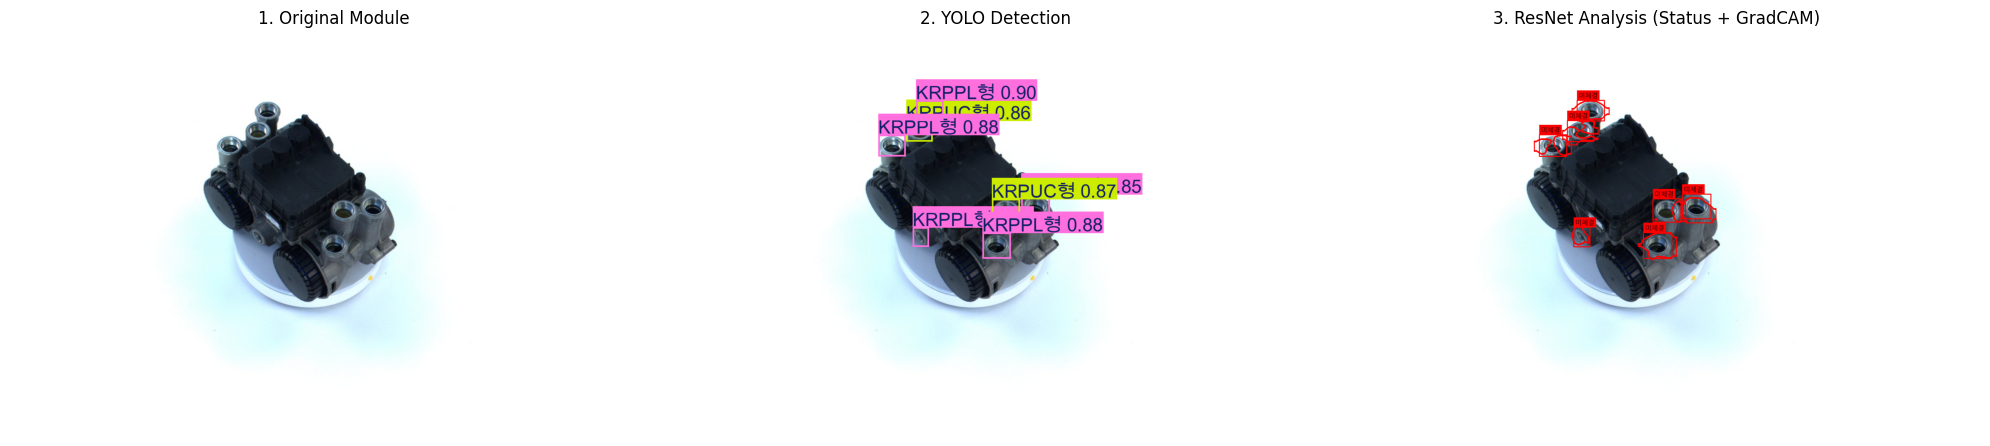


🚨 불량 감지! Vector RAG DB 검색 및 AI 근본 원인 분석(Root Cause)을 수행합니다.
고도화된 통합 LLM 진단 리포트 출력 (Powered by Gemini)
1️⃣ Gemini가 상황을 분석하여 리포트를 작성 중입니다...
2️⃣ 작성된 리포트의 신뢰도를 RAGAS로 검증 중입니다 (quota 재시도 로직 적용, 시간이 걸릴 수 있습니다)...


Evaluating:   0%|          | 0/2 [00:00<?, ?it/s]

# [공정 품질 분석 보고서] 
## 비전 검사 기반 에어피팅 미체결 불량 근본 원인 분석(RCA) 및 조치 권고사항

---

## 1. 개요 (Executive Summary)
스마트 팩토리 비전 검사 시스템을 통해 검출된 **조립 블록(밸브 매니폴드 바디)의 에어피팅 미체결(미조립) 불량**에 대한 종합 분석 보고서입니다. 

비전 센서(YOLO 및 ResNet 교차 검증)를 통해 **총 7개소의 미체결 포트**가 확인되었으며, 통계적 이력 분석 결과 이는 우발적 불량이 아닌 **설비 및 공정상의 시스템적 원인으로 발생한 고질적(Chronic) 불량**으로 판단됩니다. 본 보고서에서는 수집된 데이터와 RAG(검색 증강 생성) 기반 유사 조치 이력을 바탕으로 근본 원인을 규명하고 최종 조치 방안을 제시합니다.

---

## 2. 현재 상태 및 비전 검사 결과 분석

제공된 비전 검사 이미지와 AI 모델(YOLO, ResNet)의 판정 결과에 따르면, 조립 블록의 주요 포트에 에어피팅이 전혀 체결되지 않은 상태로 검사 영역에 진입하였습니다.

### [표 1] 미체결 검출 데이터 세부 현황
| 순번 | 검출 영역 (부품명) | 판정 상태 | YOLO 신뢰도 | ResNet 신뢰도 | 종합 판정 및 심각도 |
| :---: | :---: | :---: | :---: | :---: | :---: |
| 1 | **KRPPL형** | 미체결 | 89.75% | 100.00% | 🚨 매우 높음 (불량) |
| 2 | **KRPPL형** | 미체결 | 88.15% | 99.99% | 🚨 매우 높음 (불량) |
| 3 | **KRPPL형** | 미체결 | 88.05% | 100.00% | 🚨 매우 높음 (불량) |
| 4 | **KRPUC형** | 미체결 | 87.02% | 99.92% | 🚨 매우 높음 (불량) |
| 5 | **KRPUC형** | 미체결 | 86.21% | 99.99% | 🚨 매우 높음 (불량) |
| 6 | **KRPPL형** | 미체결 | 84.99% | 100.00% | 🚨 매우 높음 (불량) |
| 7 | **KRPPL형** | 미체결 | 77.86% | 100.00% | 🚨 매우 높음 (불량) |

* **분석 의견**: 두 검사 모델(YOLO, ResNet) 모두 85% 이상의 극히 높은 신뢰도(Confidence Score)로 에어피팅 미체결을 검출해 냈습니다. 이미지 상으로도 피팅이 조립되어야 할 나사산 포트 7곳이 완전히 노출되어 있어, **오검출(False Positive)의 가능성은 없으며 100% 미체결 불량이 확정**됩니다.

---

## 3. 통계적 반복 발생 여부 분석 (품질 트렌드)

과거 사고 로그 데이터를 분석한 결과, 본 공정은 현재 심각한 제어 상실 상태에 빠져 있을 가능성이 높습니다.

* **KRPPL형 에어피팅 미체결**: **누적 6회 발생** 
  * 2회 초과 시점부터 반복 경고가 발생했음에도 불구하고 지속되어 누적 6회에 도달했습니다. 이는 공정 내 일시적 오류가 아닌 **설비 고장 또는 지속적인 자재 공급 중단**이 발생했음을 의미합니다.
* **KRPUC형 에어피팅 미체결**: **누적 2회 발생**
  * 1회 발생 시 우발적 불량으로 추정했으나, 즉시 2회째가 검출되며 통계적 반복 기준치(2회)를 초과하여 경고 단계로 진입했습니다.
* **통계적 결론**: 특정 품목(KRPPL형)에 불량이 집중되고 있으며, 이와 인접한 KRPUC형 공정까지 연쇄적으로 불량이 발생하고 있습니다. 공정 능력(Cp/Cpk)이 무너진 상태로, **즉각적인 라인 인터록(Line Interlock) 및 설비 점검이 필요**합니다.

---

## 4. 근본 원인 분석 (Root Cause Analysis - 4M1E)

7개 포트가 동시에 누락된 현상과 높은 반복 발생 빈도를 바탕으로 도출한 근본 원인은 다음과 같습니다.

```
                  [ 4M 기반 근본 원인 트리 ]
┌─────────────────────────┬─────────────────────────┐
│  Machine (설비/장비)     │  Material (자재)        │
│  - 피팅 공급 피더(Feeder) │  - 자재 치수 불량으로    │
│    내부 잼(Jam) 현상     │    피더 내부 끼임 발생  │
│  - 흡착 노즐 압력 저하   │  - 오혼입된 이종 자재    │
├─────────────────────────┼─────────────────────────┤
│  Method (작업 표준)     │  Man (작업자)           │
│  - PLC 로봇 그리퍼 센서 │  - 피더 자재 고갈 경고  │
│    의 피킹 유무 감지 누락│    실시간 모니터링 미흡 │
└─────────────────────────┴─────────────────────────┘
```

1. **설비 요인 (Machine) - *가장 유력***
   * **자재 공급 장치(Bowl Feeder) 트러블**: KRPPL형 피팅을 정렬하여 공급해 주는 공급 장치(피더) 내에서 자재 걸림(Jam)이 발생하여 조립 로봇 부에 자재가 공급되지 않았을 가능성.
   * **로봇 그리퍼(Gripper) 및 흡착 노즐 불량**: 로봇이 피팅을 픽업(Pick-up)하는 과정에서 진압 센서나 진공 압력 센서가 정상 작동하지 않아, 빈 그리퍼로 조립 모션을 수행(공타 수행)했을 가능성.
2. **자재 요인 (Material)**
   * 피팅 부품의 사출/가공 치수 산포로 인해 조립 가이드에 끼임 현상이 발생하여 연속 미체결 유발.
3. **방법 요인 (Method)**
   * 조립 완료 후 비전 검사 단계 이전 공정에서 **'체결 유무 및 토크(Torque) 모니터링 센서'** 연동 기능이 누락되어, 조립 불량이 발생했음에도 라인이 멈추지 않고 비전 검사대까지 흘러 들어옴.

---

## 5. 최종 조치 권고사항 (Corrective & Preventive Actions)

RAG 기반 유사 조치 이력 분석 결과(`'조립블럭의 해당 영역에 KRPPL/KRPUC/KRPUL/KRPY형 에어피팅을 추가 조립함'`)를 반영하여 단기 및 장기 대책을 제시합니다.

### 5.1 즉각 조치 사항 (Immediate Actions)
1. **수동 추가 조립 (RAG 이력 반영)**:
   * 검출된 불량 제품을 즉시 Re-work 라인으로 배출합니다.
   * 유사 이력에 따라, 비전 검사기가 지정한 위치에 **KRPPL형 에어피팅 5개**와 **KRPUC형 에어피팅 2개**를 정밀 가이드에 맞춰 수동(or 수동 로봇 조작)으로 추가 조립 체결을 완료합니다.
2. **설비 비상 정지 및 라인 인터록 활성화**:
   * KRPPL형 미체결 누적 6회 발생은 심각한 이상 상태이므로 전공정 조립 로봇(설비)을 일시 정지합니다.

### 5.2 단기 예방 대책 (Short-term Preventative Actions)
1. **피팅 피더기(Feeder) 점검 및 청소**: KRPPL 및 KRPUC 공급 피더 내부의 이물질을 제거하고 끼임(Jam) 상태를 해결합니다.
2. **로봇 픽업 압력 센서 캘리브레이션**: 로봇 그리퍼가 부품을 정상적으로 잡았는지 확인하는 진공 압력(Vacuum pressure) 스위치의 임계값을 재설정합니다. 부품이 없을 경우 즉시 설비가 멈추도록 인터록을 설정합니다.

### 5.3 장기 예방 대책 (Long-term Preventative Actions)
1. **스마트 인터록 시스템 구축**:
   * 본 비전 검사 AI 시스템과 현장 **PLC 제어기를 실시간 연동**합니다.
   * 동일 불량이 2회 연속 발생(통계적 반복 경고)할 경우, 후속 공정으로 제품이 이송되지 않고 설비가 자동으로 경보(Patlite)를 울리며 멈추도록 시스템을 고도화합니다.
2. **조립 공정 내 로드셀(Load Cell) 연동**: 
   * 나사산 체결식 피팅 조립기 전단에 체결 토크 및 깊이(Stroke) 감지 센서를 추가 도입하여 상시 체결 품질 데이터를 이중 검증합니다.

---

**작성자**: 스마트 팩토리 비전 검사 AI 어시스턴트
**보고 장비 ID**: Vision_Inspection_System_#01
**상태**: 🚨 조치 요망 (Action Required)

---
## 📊 RAGAS 신뢰도 평가 결과
- **충실성 (Faithfulness):** `0.000` (검색된 과거 이력을 환각 없이 얼마나 잘 반영했는가)
- **답변 관련성 (Answer Relevancy):** `0.739` (불량 상황 해결에 얼마나 직관적이고 유용한 답변인가)


In [ ]:
from IPython.display import clear_output, display, Markdown
import random
import matplotlib.pyplot as plt

if 'test_images' in globals() and test_images:
    print("테스트 데이터셋에서 불량(이상)이 있는 이미지를 탐색합니다 (Vector RAG 적용)...")
    random.shuffle(test_images)
    anomaly_found = False

    for img_path in test_images[:50]:
        clear_output(wait=True)
        print(f"[비전 검사 진행 중] 이미지 경로: {img_path}")

        # cam 대신 target_layers를 인자로 전달합니다.
        results, final_img = run_integrated_pipeline(img_path, eval_model, classification_model, target_layers)

        has_anomaly = False
        if results:
            # 불량 판정 기준을 '정상'이 아닌 경우로 수정
            has_anomaly = any(item['status'] != '정상' for item in results)

        if has_anomaly:
            print("\n🚨 불량 감지! Vector RAG DB 검색 및 AI 근본 원인 분석(Root Cause)을 수행합니다.")
            print("==========================================")
            print("고도화된 통합 LLM 진단 리포트 출력 (Powered by Gemini)")
            print("==========================================")
            report = generate_final_report(final_img, results)

            # 마크다운 렌더링을 적용하여 깔끔하게 출력
            display(Markdown(report))

            anomaly_found = True
            break
        else:
            plt.close('all')

    if not anomaly_found:
        clear_output(wait=True)
        print("탐색한 이미지 중에서 불량을 찾지 못했습니다.")
else:
    print("테스트 이미지가 없습니다. 셀을 확인해주세요.")